In [9]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 数据目录 - 使用新的高 block num 目录
LOG_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-granuality-tests-high-block-num-2"

def parse_folder_name(folder_name):
    """从文件夹名中提取所有配置参数"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    blk_match = re.search(r'\{blk=(\d+)\}', folder_name)
    mig_match = re.search(r'\{mig=(\d+)\}', folder_name)
    vmm_match = re.search(r'\{vmm=(\d+)\}', folder_name)
    
    if pp_match and rr_match and blk_match:
        return {
            'pp_config': pp_match.group(1),
            'request_rate': float(rr_match.group(1)),
            'block_size': int(blk_match.group(1)),
            'migration': int(mig_match.group(1)) if mig_match else 0,
            'vmm': int(vmm_match.group(1)) if vmm_match else 1
        }
    return None

def parse_benchmark_log(filepath):
    """从benchmark.log末尾提取metrics: TTFT, Throughput, Normalized Latency"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        
        metrics = {}
        
        # 使用正则表达式提取metrics
        ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', content)
        throughput_match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
        normalized_latency_match = re.search(r'Mean Normalized Latency \(ms/tok\):\s+([\d.]+)', content)
        
        if ttft_match:
            metrics['ttft'] = float(ttft_match.group(1))
        if throughput_match:
            metrics['throughput'] = float(throughput_match.group(1))
        if normalized_latency_match:
            metrics['normalized_latency'] = float(normalized_latency_match.group(1))
            
        return metrics if len(metrics) == 3 else None
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None

def parse_timestamp_metrics(filepath):
    """从timestamp_metrics.csv提取KV内存利用率 (actual/allocated的平均比值)"""
    try:
        df = pd.read_csv(filepath)
        # 过滤掉 allocated=0 的行（避免除零）
        df_valid = df[df['allocated_kv_memory_bytes'] > 0]
        
        if len(df_valid) == 0:
            return None
        
        # 计算 actual/allocated 比值
        df_valid = df_valid.copy()
        df_valid['kv_utilization'] = df_valid['actual_kv_memory_bytes'] / df_valid['allocated_kv_memory_bytes']
        
        return {
            'kv_memory_utilization': df_valid['kv_utilization'].mean(),
            'kv_util_std': df_valid['kv_utilization'].std(),
            'actual_kv_mean': df_valid['actual_kv_memory_bytes'].mean(),
            'allocated_kv_mean': df_valid['allocated_kv_memory_bytes'].mean()
        }
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None

# 收集所有数据
data = []
for folder in os.listdir(LOG_DIR):
    folder_path = os.path.join(LOG_DIR, folder)
    if os.path.isdir(folder_path):
        benchmark_file = os.path.join(folder_path, "benchmark.log")
        timestamp_file = os.path.join(folder_path, "timestamp_metrics.csv")
        
        if os.path.exists(benchmark_file):
            config = parse_folder_name(folder)
            if config:
                metrics = parse_benchmark_log(benchmark_file)
                if metrics:
                    row = {**config, **metrics}
                    
                    # 尝试解析 timestamp_metrics
                    if os.path.exists(timestamp_file):
                        kv_metrics = parse_timestamp_metrics(timestamp_file)
                        if kv_metrics:
                            row.update(kv_metrics)
                    
                    data.append(row)

df = pd.DataFrame(data)
print(f"收集到 {len(df)} 个实验数据点")
print(f"PP Configs: {sorted(df['pp_config'].unique())}")
print(f"Request Rates: {sorted(df['request_rate'].unique())}")
print(f"Block Sizes: {sorted(df['block_size'].unique())}")
print(f"\n列名: {df.columns.tolist()}")
df

收集到 10 个实验数据点
PP Configs: ['36-44', '40-40', '48-32']
Request Rates: [1.5, 3.0]
Block Sizes: [32, 64, 128, 256, 512]

列名: ['pp_config', 'request_rate', 'block_size', 'migration', 'vmm', 'ttft', 'throughput', 'normalized_latency', 'kv_memory_utilization', 'kv_util_std', 'actual_kv_mean', 'allocated_kv_mean']


,pp_config,request_rate,block_size,migration,vmm,ttft,throughput,normalized_latency,kv_memory_utilization,kv_util_std,actual_kv_mean,allocated_kv_mean
0,40-40,3.0,64,1,1,4679.95,240.78,963.52,0.936846,0.029883,6.319454e+09,6.735272e+09
1,36-44,3.0,256,1,1,4625.74,248.47,513.72,0.739870,0.069784,4.639057e+09,6.326571e+09
2,36-44,1.5,128,1,1,443.61,175.84,191.92,0.850298,0.050936,2.448430e+09,2.877992e+09
3,48-32,1.5,32,0,1,433.89,168.42,209.02,0.956527,0.013525,2.672590e+09,2.790565e+09
4,36-44,1.5,512,1,0,477.27,177.00,190.23,0.555468,0.082910,2.535238e+09,4.381650e+09
5,36-44,3.0,512,1,0,8264.28,251.52,579.45,0.571835,0.128634,4.505957e+09,8.045438e+09
6,40-40,1.5,64,1,1,465.87,179.70,201.77,0.932661,0.032011,2.633258e+09,2.849720e+09
7,48-32,3.0,32,0,1,4799.49,233.83,1152.26,0.955709,0.015909,7.360968e+09,7.710909e+09
8,36-44,1.5,256,1,1,463.95,169.15,190.51,0.742009,0.043264,2.366054e+09,3.182170e+09
9,36-44,3.0,128,1,1,4011.53,240.10,535.74,0.848232,0.053528,4.832843e+09,5.724226e+09


聚合后数据:
   request_rate  block_size     ttft  throughput  normalized_latency  \
0           1.5          32   433.89      168.42              209.02   
1           1.5          64   465.87      179.70              201.77   
2           1.5         128   443.61      175.84              191.92   
3           1.5         256   463.95      169.15              190.51   
4           1.5         512   477.27      177.00              190.23   
5           3.0          32  4799.49      233.83             1152.26   
6           3.0          64  4679.95      240.78              963.52   
7           3.0         128  4011.53      240.10              535.74   
8           3.0         256  4625.74      248.47              513.72   
9           3.0         512  8264.28      251.52              579.45   

   kv_memory_utilization  granularity  
0               0.956527           16  
1               0.932661            8  
2               0.850298            4  
3               0.742009            2  


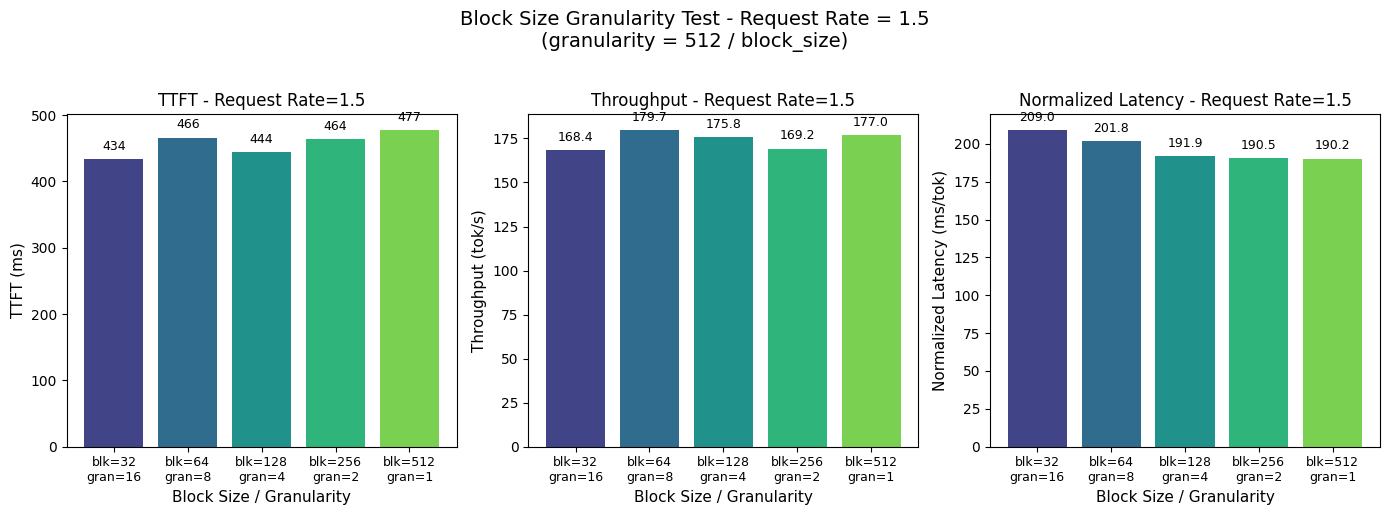

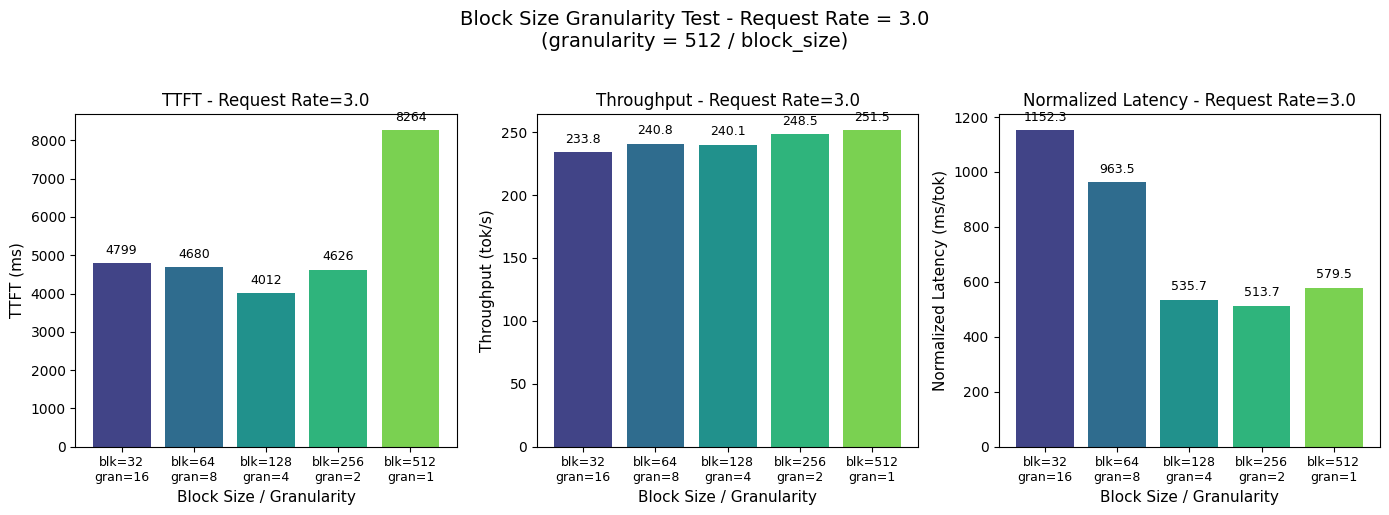


KV Memory Utilization (actual/allocated ratio)
   block_size  kv_util_mean  kv_util_std  granularity
0          32      0.956118     0.000578           16
1          64      0.934754     0.002959            8
2         128      0.849265     0.001461            4
3         256      0.740940     0.001512            2
4         512      0.563651     0.011573            1

有效数据点: 5


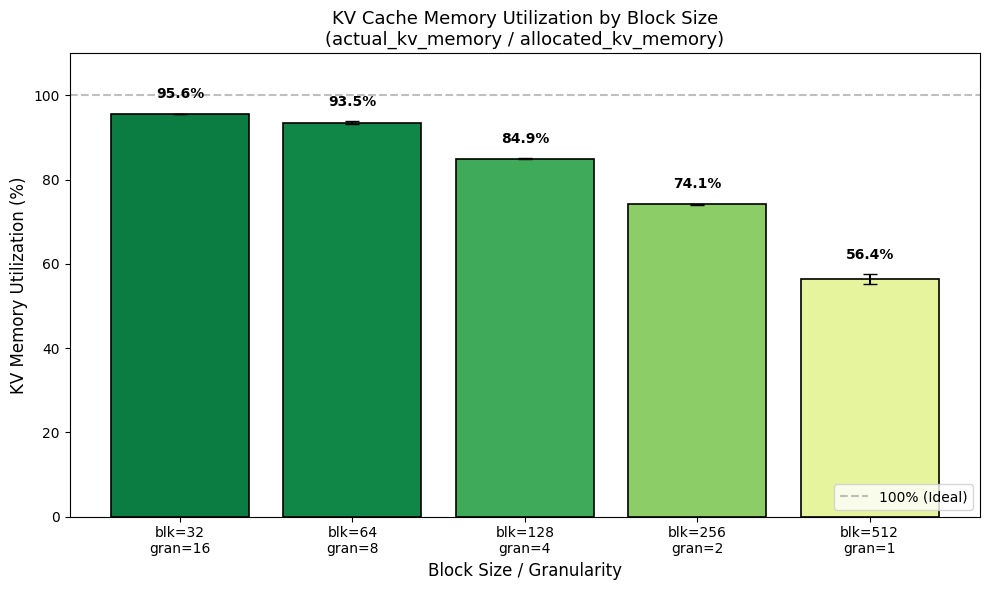


Internal Fragmentation Analysis:
Block Size 32 (granularity=16): Utilization=95.6%, Memory Waste=4.4%
Block Size 64 (granularity=8): Utilization=93.5%, Memory Waste=6.5%
Block Size 128 (granularity=4): Utilization=84.9%, Memory Waste=15.1%
Block Size 256 (granularity=2): Utilization=74.1%, Memory Waste=25.9%
Block Size 512 (granularity=1): Utilization=56.4%, Memory Waste=43.6%


In [10]:
# 计算granularity: granularity = 512 / block_size
df['granularity'] = 512 // df['block_size']

# 按 block_size 和 request_rate 聚合数据
df_agg = df.groupby(['request_rate', 'block_size']).agg({
    'ttft': 'mean',
    'throughput': 'mean',
    'normalized_latency': 'mean',
    'kv_memory_utilization': 'mean'
}).reset_index()

# 添加granularity列
df_agg['granularity'] = 512 // df_agg['block_size']

print("聚合后数据:")
print(df_agg)

# 获取所有唯一的 request rates
request_rates = sorted(df_agg['request_rate'].unique())
block_sizes = sorted(df_agg['block_size'].unique())
print(f"\nRequest Rates: {request_rates}")
print(f"Block Sizes: {block_sizes}")

# 为每个 request rate 绘制一组图 (TTFT, Throughput, Normalized Latency)
for rr in request_rates:
    df_rr = df_agg[df_agg['request_rate'] == rr].sort_values('block_size')
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    # 颜色映射
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_rr)))
    # X标签包含block_size和granularity
    x_labels = [f'blk={b}\ngran={512//b}' for b in df_rr['block_size']]
    
    # TTFT 柱状图
    bars0 = axes[0].bar(range(len(df_rr)), df_rr['ttft'], color=colors)
    axes[0].set_xticks(range(len(df_rr)))
    axes[0].set_xticklabels(x_labels, rotation=0, fontsize=9)
    axes[0].set_ylabel('TTFT (ms)', fontsize=11)
    axes[0].set_xlabel('Block Size / Granularity', fontsize=11)
    axes[0].set_title(f'TTFT - Request Rate={rr}', fontsize=12)
    for i, v in enumerate(df_rr['ttft']):
        axes[0].text(i, v + max(df_rr['ttft'])*0.02, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
    
    # Throughput 柱状图
    bars1 = axes[1].bar(range(len(df_rr)), df_rr['throughput'], color=colors)
    axes[1].set_xticks(range(len(df_rr)))
    axes[1].set_xticklabels(x_labels, rotation=0, fontsize=9)
    axes[1].set_ylabel('Throughput (tok/s)', fontsize=11)
    axes[1].set_xlabel('Block Size / Granularity', fontsize=11)
    axes[1].set_title(f'Throughput - Request Rate={rr}', fontsize=12)
    for i, v in enumerate(df_rr['throughput']):
        axes[1].text(i, v + max(df_rr['throughput'])*0.02, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    
    # Normalized Latency 柱状图
    bars2 = axes[2].bar(range(len(df_rr)), df_rr['normalized_latency'], color=colors)
    axes[2].set_xticks(range(len(df_rr)))
    axes[2].set_xticklabels(x_labels, rotation=0, fontsize=9)
    axes[2].set_ylabel('Normalized Latency (ms/tok)', fontsize=11)
    axes[2].set_xlabel('Block Size / Granularity', fontsize=11)
    axes[2].set_title(f'Normalized Latency - Request Rate={rr}', fontsize=12)
    for i, v in enumerate(df_rr['normalized_latency']):
        axes[2].text(i, v + max(df_rr['normalized_latency'])*0.02, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(f'Block Size Granularity Test - Request Rate = {rr}\n(granularity = 512 / block_size)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'/home/bxb1/vllm_workbench/vllm/draws/granularity_blk_rr{rr}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==================== 单独绘制 KV Memory Utilization 图 ====================
print("\n" + "=" * 60)
print("KV Memory Utilization (actual/allocated ratio)")
print("=" * 60)

# 按 block_size 聚合（跨所有 request_rate）
df_kv_agg = df.groupby('block_size').agg({
    'kv_memory_utilization': ['mean', 'std']
}).reset_index()
df_kv_agg.columns = ['block_size', 'kv_util_mean', 'kv_util_std']
df_kv_agg = df_kv_agg.sort_values('block_size')
df_kv_agg['granularity'] = 512 // df_kv_agg['block_size']

# 过滤掉 NaN 数据 (vmm=0 没有 KV stats)
df_kv_valid = df_kv_agg.dropna(subset=['kv_util_mean'])

print(df_kv_agg)
print(f"\n有效数据点: {len(df_kv_valid)}")

# 绘制 KV Memory Utilization 图
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_kv_valid))
x_labels = [f'blk={int(b)}\ngran={int(512//b)}' for b in df_kv_valid['block_size']]
colors = plt.cm.RdYlGn(df_kv_valid['kv_util_mean'])  # 颜色映射：红(低)->黄->绿(高)

bars = ax.bar(x, df_kv_valid['kv_util_mean'] * 100, 
              yerr=df_kv_valid['kv_util_std'] * 100, 
              color=colors, capsize=5, edgecolor='black', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('KV Memory Utilization (%)', fontsize=12)
ax.set_xlabel('Block Size / Granularity', fontsize=12)
ax.set_title('KV Cache Memory Utilization by Block Size\n(actual_kv_memory / allocated_kv_memory)', fontsize=13)
ax.set_ylim(0, 110)

# 添加数值标签
for i, (mean, std) in enumerate(zip(df_kv_valid['kv_util_mean'], df_kv_valid['kv_util_std'])):
    ax.text(i, mean * 100 + std * 100 + 3, f'{mean*100:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 添加参考线
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100% (Ideal)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/granularity_kv_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印内存利用率分析
print("\n" + "=" * 60)
print("Internal Fragmentation Analysis:")
print("=" * 60)
for _, row in df_kv_valid.iterrows():
    waste = (1 - row['kv_util_mean']) * 100
    print(f"Block Size {int(row['block_size'])} (granularity={int(row['granularity'])}): "
          f"Utilization={row['kv_util_mean']*100:.1f}%, "
          f"Memory Waste={waste:.1f}%")

In [3]:
# ==================== 分析不同粒度对最佳配置的覆盖率 ====================
# 从config_cmp的数据目录读取数据
CONFIG_CMP_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-config-finder-llama"

def parse_folder_name_full(folder_name):
    """从文件夹名中提取pp config, request rate和workload类型"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    in_match = re.search(r'\{in=(\d+)\}', folder_name)
    out_match = re.search(r'\{out=(\d+)\}', folder_name)
    
    if pp_match and rr_match and in_match and out_match:
        workload = f"in{in_match.group(1)}_out{out_match.group(1)}"
        return pp_match.group(1), float(rr_match.group(1)), workload
    return None, None, None

# 收集config_cmp的所有数据
config_data = []
for folder in os.listdir(CONFIG_CMP_DIR):
    folder_path = os.path.join(CONFIG_CMP_DIR, folder)
    if os.path.isdir(folder_path):
        benchmark_file = os.path.join(folder_path, "benchmark.log")
        if os.path.exists(benchmark_file):
            pp_config, request_rate, workload = parse_folder_name_full(folder)
            if pp_config and request_rate and workload:
                metrics = parse_benchmark_log(benchmark_file)
                if metrics:
                    config_data.append({
                        'pp_config': pp_config,
                        'request_rate': request_rate,
                        'workload': workload,
                        **metrics
                    })

df_config = pd.DataFrame(config_data)
print(f"收集到 {len(df_config)} 个config_cmp实验数据点")
print(f"Workloads: {df_config['workload'].unique()}")
print(f"PP Configs: {sorted(df_config['pp_config'].unique(), key=lambda x: int(x.split('-')[0]))}")
df_config.head()

收集到 168 个config_cmp实验数据点
Workloads: ['in512_out16' 'in128_out512']
PP Configs: ['36-44', '38-42', '40-40', '42-38', '44-36', '46-34', '48-32', '50-30', '52-28', '54-26', '56-24', '58-22', '60-20', '62-18', '64-16', '66-14']


,pp_config,request_rate,workload,ttft,tpot,throughput
0,48-32,1.0,in512_out16,558.31,143.89,15.61
1,62-18,2.0,in512_out16,1946.19,1047.39,30.33
2,38-42,3.0,in512_out16,3985.90,715.18,38.23
3,40-40,2.5,in128_out512,245.34,140.59,266.11
4,42-38,1.5,in512_out16,655.31,289.11,23.14


In [4]:
# 定义检查配置是否能被某个粒度覆盖的函数
def can_cover_config(pp_config, granularity, base=36):
    """
    检查某个pp_config是否能被给定粒度覆盖
    粒度决定了可配置的层数，从base开始，每隔granularity个layer可以有一个配置
    例如：granularity=4，base=36，则可配置 36, 40, 44, 48...
    """
    prefill = int(pp_config.split('-')[0])
    return (prefill - base) % granularity == 0

# 计算每个(workload, request_rate)组合下的最佳配置
def find_best_configs(df, metrics=['ttft', 'tpot', 'throughput']):
    """找出每个场景下各个metric的最佳配置"""
    best_configs = {}
    
    for workload in df['workload'].unique():
        for rr in df[df['workload'] == workload]['request_rate'].unique():
            df_subset = df[(df['workload'] == workload) & (df['request_rate'] == rr)]
            
            key = (workload, rr)
            best_configs[key] = {}
            
            # TTFT和TPOT：越低越好
            for metric in ['ttft', 'tpot']:
                best_idx = df_subset[metric].idxmin()
                best_configs[key][metric] = df_subset.loc[best_idx, 'pp_config']
            
            # Throughput：越高越好
            best_idx = df_subset['throughput'].idxmax()
            best_configs[key]['throughput'] = df_subset.loc[best_idx, 'pp_config']
    
    return best_configs

best_configs = find_best_configs(df_config)

# 打印每个场景的最佳配置
print("=" * 60)
print("每个场景下的最佳配置:")
print("=" * 60)
for (workload, rr), metrics in best_configs.items():
    print(f"\n{workload}, rr={rr}:")
    for metric, config in metrics.items():
        print(f"  {metric}: {config}")

每个场景下的最佳配置:

in512_out16, rr=1.0:
  ttft: 36-44
  tpot: 66-14
  throughput: 66-14

in512_out16, rr=2.0:
  ttft: 36-44
  tpot: 36-44
  throughput: 50-30

in512_out16, rr=3.0:
  ttft: 38-42
  tpot: 36-44
  throughput: 38-42

in512_out16, rr=1.5:
  ttft: 36-44
  tpot: 36-44
  throughput: 62-18

in512_out16, rr=2.5:
  ttft: 48-32
  tpot: 36-44
  throughput: 48-32

in512_out16, rr=0.5:
  ttft: 38-42
  tpot: 66-14
  throughput: 62-18

in128_out512, rr=2.5:
  ttft: 42-38
  tpot: 52-28
  throughput: 52-28

in128_out512, rr=1.0:
  ttft: 52-28
  tpot: 66-14
  throughput: 66-14

in128_out512, rr=1.5:
  ttft: 40-40
  tpot: 56-24
  throughput: 56-24

in128_out512, rr=0.5:
  ttft: 38-42
  tpot: 66-14
  throughput: 54-26

in128_out512, rr=2.0:
  ttft: 42-38
  tpot: 52-28
  throughput: 54-26


In [5]:
# 计算不同粒度对最佳配置的覆盖率
granularities = [2, 4, 8, 16]
metrics_list = ['ttft', 'tpot', 'throughput']

# 存储覆盖率结果
coverage_results = {g: {m: 0 for m in metrics_list} for g in granularities}
coverage_details = {g: {m: [] for m in metrics_list} for g in granularities}

total_scenarios = len(best_configs)

for granularity in granularities:
    for metric in metrics_list:
        covered = 0
        for (workload, rr), best in best_configs.items():
            best_config = best[metric]
            if can_cover_config(best_config, granularity):
                covered += 1
                coverage_details[granularity][metric].append((workload, rr, best_config, "✓"))
            else:
                coverage_details[granularity][metric].append((workload, rr, best_config, "✗"))
        
        coverage_results[granularity][metric] = covered / total_scenarios * 100

# 打印覆盖率结果
print("=" * 70)
print("不同粒度对最佳配置的覆盖率 (%):")
print("=" * 70)
print(f"{'Granularity':<12} {'TTFT':<12} {'TPOT':<12} {'Throughput':<12}")
print("-" * 70)
for g in granularities:
    print(f"{g:<12} {coverage_results[g]['ttft']:<12.1f} {coverage_results[g]['tpot']:<12.1f} {coverage_results[g]['throughput']:<12.1f}")

# 创建覆盖率DataFrame
coverage_df = pd.DataFrame(coverage_results).T
coverage_df.index.name = 'Granularity'
coverage_df.columns = ['TTFT (%)', 'TPOT (%)', 'Throughput (%)']
print("\n覆盖率表格:")
coverage_df

不同粒度对最佳配置的覆盖率 (%):
Granularity  TTFT         TPOT         Throughput  
----------------------------------------------------------------------
2            100.0        100.0        100.0       
4            54.5         63.6         27.3        
8            36.4         54.5         9.1         
16           36.4         54.5         9.1         

覆盖率表格:


,TTFT (%),TPOT (%),Throughput (%)
Granularity,,,
2,100.000000,100.000000,100.000000
4,54.545455,63.636364,27.272727
8,36.363636,54.545455,9.090909
16,36.363636,54.545455,9.090909


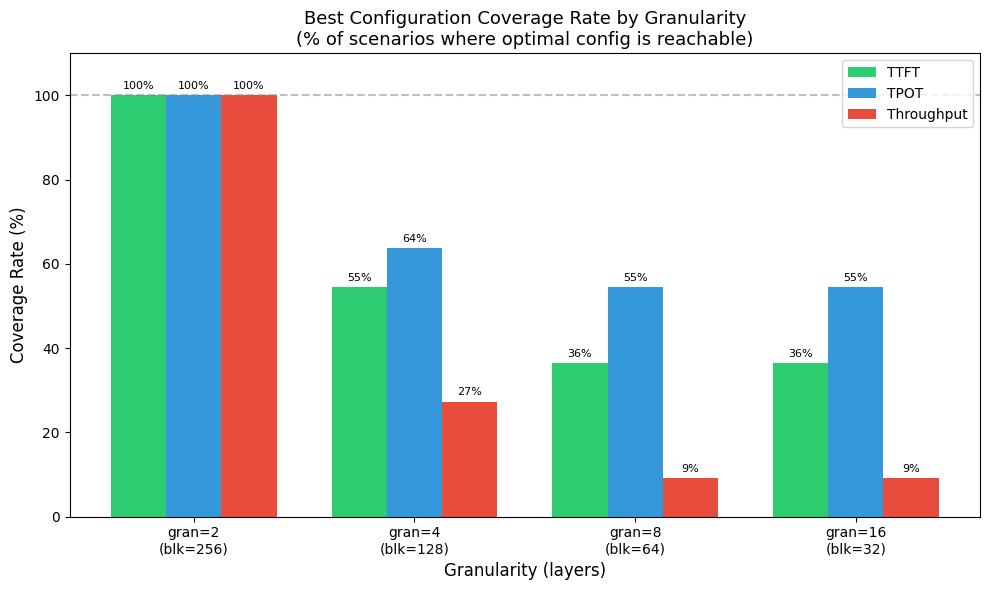


详细覆盖情况 (✓=可覆盖, ✗=无法覆盖):

粒度 2 (block_size=256):

粒度 4 (block_size=128):
  ttft 未覆盖的场景:
    - in512_out16, rr=3.0: 最佳配置 38-42
    - in512_out16, rr=0.5: 最佳配置 38-42
    - in128_out512, rr=2.5: 最佳配置 42-38
    - in128_out512, rr=0.5: 最佳配置 38-42
    - in128_out512, rr=2.0: 最佳配置 42-38
  tpot 未覆盖的场景:
    - in512_out16, rr=1.0: 最佳配置 66-14
    - in512_out16, rr=0.5: 最佳配置 66-14
    - in128_out512, rr=1.0: 最佳配置 66-14
    - in128_out512, rr=0.5: 最佳配置 66-14
  throughput 未覆盖的场景:
    - in512_out16, rr=1.0: 最佳配置 66-14
    - in512_out16, rr=2.0: 最佳配置 50-30
    - in512_out16, rr=3.0: 最佳配置 38-42
    - in512_out16, rr=1.5: 最佳配置 62-18
    - in512_out16, rr=0.5: 最佳配置 62-18
    - in128_out512, rr=1.0: 最佳配置 66-14
    - in128_out512, rr=0.5: 最佳配置 54-26
    - in128_out512, rr=2.0: 最佳配置 54-26

粒度 8 (block_size=64):
  ttft 未覆盖的场景:
    - in512_out16, rr=3.0: 最佳配置 38-42
    - in512_out16, rr=2.5: 最佳配置 48-32
    - in512_out16, rr=0.5: 最佳配置 38-42
    - in128_out512, rr=2.5: 最佳配置 42-38
    - in128_out512, rr=1.5: 最佳配

In [6]:
# 可视化覆盖率
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(granularities))
width = 0.25

bars1 = ax.bar(x - width, [coverage_results[g]['ttft'] for g in granularities], width, label='TTFT', color='#2ecc71')
bars2 = ax.bar(x, [coverage_results[g]['tpot'] for g in granularities], width, label='TPOT', color='#3498db')
bars3 = ax.bar(x + width, [coverage_results[g]['throughput'] for g in granularities], width, label='Throughput', color='#e74c3c')

ax.set_xlabel('Granularity (layers)', fontsize=12)
ax.set_ylabel('Coverage Rate (%)', fontsize=12)
ax.set_title('Best Configuration Coverage Rate by Granularity\n(% of scenarios where optimal config is reachable)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'gran={g}\n(blk={512//g})' for g in granularities], fontsize=10)
ax.legend(loc='upper right')
ax.set_ylim(0, 110)

# 添加数值标签
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100%')
plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/granularity_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印详细覆盖情况
print("\n" + "=" * 80)
print("详细覆盖情况 (✓=可覆盖, ✗=无法覆盖):")
print("=" * 80)
for g in granularities:
    print(f"\n粒度 {g} (block_size={512//g}):")
    for metric in metrics_list:
        uncovered = [item for item in coverage_details[g][metric] if item[3] == "✗"]
        if uncovered:
            print(f"  {metric} 未覆盖的场景:")
            for workload, rr, config, status in uncovered:
                print(f"    - {workload}, rr={rr}: 最佳配置 {config}")